# Error Rate Benchmark Analysis - 200K Reads

This notebook analyzes the benchmark results for three barcode calling tools (RandomBarcodes, QUIK, and Columba) tested on 200K simulated reads with varying error rates and barcode set sizes.

## Experiment Design

- **Tools**: RandomBarcodes, QUIK, Columba
- **Barcode Counts**: 21K, 42K, 85K unique barcodes
- **Barcode Length**: 36 nucleotides
- **Error Rates**: Low, Medium, High
- **Total Reads**: 200,000 per experiment
- **Total Experiments**: 27 (3 tools × 3 barcode counts × 3 error rates)

## Tool Parameters

### RandomBarcodes
- nthresh: 9
- ntriage: 100
- GPUs: 2

### QUIK
- Strategy: 4_mer_gpu_v4
- Rejection threshold: 8
- GPUs: 1

### Columba
- Identity threshold: 80%
- CPUs: 16

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Data Loading

Load precision/recall metrics from all 27 experiments.

In [2]:
# Define paths
results_base = Path("/user/gent/446/vsc44685/ScratchVO_dir/barcalling_review/BarCall_benchmark/error_rate_benchmark/results")

# Tools and their configurations
tools = ['randombarcodes', 'quik', 'columba']
barcode_counts = ['21K', '42K', '85K']
error_rates = ['low', 'medium', 'high']

# Initialize data structure
data_list = []

# Iterate through all combinations
for tool in tools:
    for bc_count in barcode_counts:
        for error_rate in error_rates:
            # Construct directory name
            exp_name = f"{tool}_{bc_count}_36nt_{error_rate}"
            result_dir = results_base / exp_name
            
            # Look for precision summary file
            if tool == 'columba':
                summary_file = result_dir / exp_name / f"{exp_name}_precision_summary.csv"
            else:
                summary_file = result_dir / exp_name / f"{exp_name}_precision_summary.csv"
            
            if summary_file.exists():
                # Read precision summary
                df_temp = pd.read_csv(summary_file, header=0)
                
                # Convert to dictionary format
                metrics = {}
                for _, row in df_temp.iterrows():
                    metrics[row['metric']] = row['value']
                
                # Add metadata
                metrics['tool'] = tool.upper() if tool == 'quik' else tool.capitalize()
                metrics['barcode_count'] = bc_count
                metrics['error_rate'] = error_rate
                metrics['experiment'] = exp_name
                
                data_list.append(metrics)
                print(f"✓ Loaded: {exp_name}")
            else:
                print(f"✗ Missing: {exp_name}")

# Create DataFrame
df = pd.DataFrame(data_list)

print(f"\n{'='*60}")
print(f"Total experiments loaded: {len(df)} / 27")
print(f"{'='*60}")

✓ Loaded: randombarcodes_21K_36nt_low
✓ Loaded: randombarcodes_21K_36nt_medium
✓ Loaded: randombarcodes_21K_36nt_high
✓ Loaded: randombarcodes_42K_36nt_low
✓ Loaded: randombarcodes_42K_36nt_medium
✓ Loaded: randombarcodes_42K_36nt_high
✓ Loaded: randombarcodes_85K_36nt_low
✓ Loaded: randombarcodes_85K_36nt_medium
✓ Loaded: randombarcodes_85K_36nt_high
✓ Loaded: quik_21K_36nt_low
✓ Loaded: quik_21K_36nt_medium
✓ Loaded: quik_21K_36nt_high
✓ Loaded: quik_42K_36nt_low
✓ Loaded: quik_42K_36nt_medium
✓ Loaded: quik_42K_36nt_high
✓ Loaded: quik_85K_36nt_low
✓ Loaded: quik_85K_36nt_medium
✓ Loaded: quik_85K_36nt_high
✓ Loaded: columba_21K_36nt_low
✓ Loaded: columba_21K_36nt_medium
✓ Loaded: columba_21K_36nt_high
✓ Loaded: columba_42K_36nt_low
✓ Loaded: columba_42K_36nt_medium
✓ Loaded: columba_42K_36nt_high
✓ Loaded: columba_85K_36nt_low
✓ Loaded: columba_85K_36nt_medium
✓ Loaded: columba_85K_36nt_high

Total experiments loaded: 27 / 27


In [3]:
# Clean up column names and calculate additional metrics
df = df.rename(columns={
    'precision_percent': 'precision',
    'recall_percent': 'recall',
    'accuracy_percent': 'accuracy',
    'assignment_rate_percent': 'assignment_rate'
})

# Calculate F1 score if not present
if 'f1_score' not in df.columns:
    df['f1_score'] = 2 * (df['precision'] * df['recall']) / (df['precision'] + df['recall'])

# Convert barcode count to numeric for sorting
df['bc_count_num'] = df['barcode_count'].str.replace('K', '').astype(int) * 1000

# Create ordered categories for plotting
df['error_rate'] = pd.Categorical(df['error_rate'], categories=['low', 'medium', 'high'], ordered=True)
df['barcode_count'] = pd.Categorical(df['barcode_count'], categories=['21K', '42K', '85K'], ordered=True)

# Display first few rows
print("Sample of loaded data:")
display(df[['tool', 'barcode_count', 'error_rate', 'precision', 'recall', 'f1_score']].head(25))

Sample of loaded data:


,tool,barcode_count,error_rate,precision,recall,f1_score
0,Randombarcodes,21K,low,99.9497,64.6150,78.488884
1,Randombarcodes,21K,medium,99.9422,56.1730,71.921929
2,Randombarcodes,21K,high,99.9057,40.7780,57.916512
3,Randombarcodes,42K,low,99.9233,64.4840,78.384039
4,Randombarcodes,42K,medium,99.9040,56.1840,71.921049
5,Randombarcodes,42K,high,99.8019,40.8105,57.931810
6,Randombarcodes,85K,low,99.8740,64.2120,78.167659
7,Randombarcodes,85K,medium,99.8289,56.0065,71.756062
8,Randombarcodes,85K,high,99.6741,40.5265,57.623754
9,QUIK,21K,low,99.9424,93.6265,96.681410


## 2. Summary Statistics

Overall performance metrics for each tool across all conditions.

In [4]:
# Summary statistics by tool
summary_by_tool = df.groupby('tool')[['precision', 'recall', 'f1_score', 'assignment_rate']].agg(['mean', 'std', 'min', 'max'])

print("="*80)
print("SUMMARY STATISTICS BY TOOL")
print("="*80)
display(summary_by_tool.round(2))

# Best configuration for each tool
print("\n" + "="*80)
print("BEST F1 SCORE FOR EACH TOOL")
print("="*80)
best_configs = df.loc[df.groupby('tool')['f1_score'].idxmax()][['tool', 'barcode_count', 'error_rate', 'precision', 'recall', 'f1_score']]
display(best_configs)

SUMMARY STATISTICS BY TOOL


precision                     recall                       \
                    mean   std    min    max   mean    std    min    max   
tool                                                                       
Columba            99.96  0.02  99.92  99.99  35.85   6.78  28.12  44.02   
QUIK               99.57  0.47  98.48  99.94  81.17  14.14  62.00  93.63   
Randombarcodes     99.87  0.09  99.67  99.95  53.75  10.43  40.53  64.61   

               f1_score                     assignment_rate                \
                   mean   std    min    max            mean    std    min   
tool                                                                        
Columba           52.45  7.34  43.90  61.13           35.86   6.78  28.14   
QUIK              88.83  9.19  76.09  96.68           81.47  13.93  62.96   
Randombarcodes    69.35  9.09  57.62  78.49           53.82  10.42  40.66   

                       
                  max  
tool                   
Columba         44.03  
QUIK            93.68  
Randombarcodes  64.65


BEST F1 SCORE FOR EACH TOOL


,tool,barcode_count,error_rate,precision,recall,f1_score
18,Columba,21K,low,99.9898,44.0215,61.129939
9,QUIK,21K,low,99.9424,93.6265,96.681410
0,Randombarcodes,21K,low,99.9497,64.6150,78.488884


## 3. Performance Comparison Tables

Detailed tables showing performance metrics for each combination of tool, barcode count, and error rate.

In [5]:
# Create pivot table for precision
precision_table = df.pivot_table(values='precision', index=['tool', 'barcode_count'], columns='error_rate', aggfunc='first')
print("="*60)
print("PRECISION (%) BY TOOL, BARCODE COUNT, AND ERROR RATE")
print("="*60)
display(precision_table.round(2))

# Create pivot table for recall
recall_table = df.pivot_table(values='recall', index=['tool', 'barcode_count'], columns='error_rate', aggfunc='first')
print("\n" + "="*60)
print("RECALL (%) BY TOOL, BARCODE COUNT, AND ERROR RATE")
print("="*60)
display(recall_table.round(2))

# Create pivot table for F1 score
f1_table = df.pivot_table(values='f1_score', index=['tool', 'barcode_count'], columns='error_rate', aggfunc='first')
print("\n" + "="*60)
print("F1 SCORE BY TOOL, BARCODE COUNT, AND ERROR RATE")
print("="*60)
display(f1_table.round(2))

PRECISION (%) BY TOOL, BARCODE COUNT, AND ERROR RATE


error_rate                      low  medium   high
tool           barcode_count                      
Columba        21K            99.99   99.98  99.98
               42K            99.97   99.97  99.96
               85K            99.96   99.94  99.92
QUIK           21K            99.94   99.90  99.59
               42K            99.88   99.78  99.21
               85K            99.75   99.59  98.48
Randombarcodes 21K            99.95   99.94  99.91
               42K            99.92   99.90  99.80
               85K            99.87   99.83  99.67


RECALL (%) BY TOOL, BARCODE COUNT, AND ERROR RATE


error_rate                      low  medium   high
tool           barcode_count                      
Columba        21K            44.02   35.54  28.28
               42K            43.93   35.49  28.12
               85K            43.63   35.37  28.27
QUIK           21K            93.63   88.57  63.08
               42K            93.11   87.94  62.63
               85K            92.41   87.12  62.00
Randombarcodes 21K            64.61   56.17  40.78
               42K            64.48   56.18  40.81
               85K            64.21   56.01  40.53


F1 SCORE BY TOOL, BARCODE COUNT, AND ERROR RATE


error_rate                      low  medium   high
tool           barcode_count                      
Columba        21K            61.13   52.44  44.08
               42K            61.04   52.38  43.90
               85K            60.75   52.24  44.07
QUIK           21K            96.68   93.89  77.24
               42K            96.37   93.49  76.79
               85K            95.94   92.94  76.09
Randombarcodes 21K            78.49   71.92  57.92
               42K            78.38   71.92  57.93
               85K            78.17   71.76  57.62

In [9]:
tool_data

,total_reads,total_assigned,correct_assignments,incorrect_assignments,unassigned_reads,assignment_rate,precision,recall,accuracy,tool,barcode_count,error_rate,experiment,total_processed,f1_score,bc_count_num
18,200000.0,NaN,86571.0,1691.0,111738.0,44.1310,98.0841,43.2855,43.2855,Columba,21K,low,columba_21K_36nt_low,200000.0,60.064106,21000
19,200000.0,NaN,69921.0,1384.0,128695.0,35.6525,98.0590,34.9605,34.9605,Columba,21K,medium,columba_21K_36nt_medium,200000.0,51.544197,21000
20,200000.0,NaN,55586.0,1104.0,143310.0,28.3450,98.0526,27.7930,27.7930,Columba,21K,high,columba_21K_36nt_high,200000.0,43.309832,21000
21,200000.0,NaN,85002.0,3566.0,111432.0,44.2840,95.9737,42.5010,42.5010,Columba,42K,low,columba_42K_36nt_low,200000.0,58.912974,42000
22,200000.0,NaN,68746.0,2820.0,128434.0,35.7830,96.0596,34.3730,34.3730,Columba,42K,medium,columba_42K_36nt_medium,200000.0,50.629316,42000
23,200000.0,NaN,54380.0,2179.0,143441.0,28.2795,96.1474,27.1900,27.1900,Columba,42K,high,columba_42K_36nt_high,200000.0,42.391810,42000
24,200000.0,NaN,82087.0,7007.0,110906.0,44.5470,92.1353,41.0435,41.0435,Columba,85K,low,columba_85K_36nt_low,200000.0,56.789146,85000
25,200000.0,NaN,66416.0,5943.0,127641.0,36.1795,91.7868,33.2080,33.2080,Columba,85K,medium,columba_85K_36nt_medium,200000.0,48.770926,85000
26,200000.0,NaN,53116.0,4280.0,142604.0,28.6980,92.5430,26.5580,26.5580,Columba,85K,high,columba_85K_36nt_high,200000.0,41.271811,85000


## 4. Precision vs Recall Scatter Plot

Visualize the precision-recall trade-off for all tools, with color-coded error rates and different markers for barcode sizes.

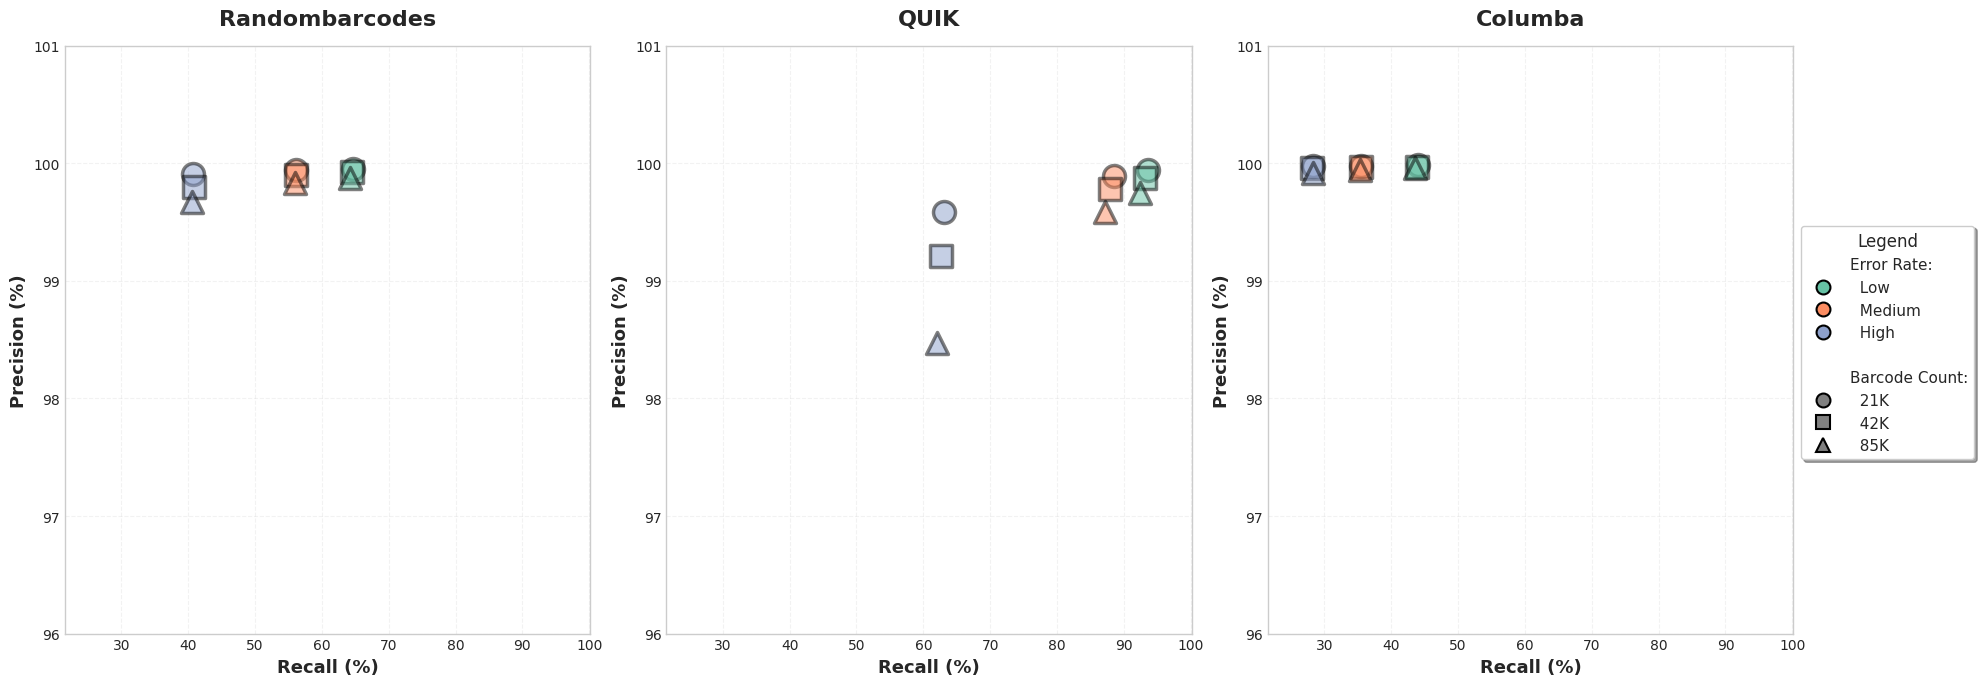

✓ Plot saved: figures/errorrate_precision_recall.pdf

📊 Visualization shows 27 discrete experiments (3 tools × 3 barcode counts × 3 error rates)
   Color = error rate (green=low, orange=medium, red=high)
   Shape = barcode count (circle=21K, square=42K, triangle=85K)


In [10]:
# Create scatter plots showing discrete experimental configurations with annotations
error_palette = sns.color_palette("Set2", n_colors=3)
#error_colors = {'low': '#27ae60', 'medium': '#f39c12', 'high': '#e74c3c'}
error_colors = {'low': error_palette[0], 'medium': error_palette[1], 'high': error_palette[2]}
bc_markers = {'21K': 'o', '42K': 's', '85K': '^'}

# Calculate global axis limits across all tools for comparability
recall_min = df['recall'].min()
recall_max = df['recall'].max()
prec_min = df['precision'].min()
prec_max = df['precision'].max()

recall_range = recall_max - recall_min
prec_range = prec_max - prec_min

# Set common limits with padding
xlim = [max(0, recall_min - recall_range*0.1), recall_max + recall_range*0.1]
# Increase y-axis upper limit to give more space at the top
#ylim = [max(0, prec_min - max(prec_range*0.1, 2)), min(102, prec_max + max(prec_range*0.15, 3))]
ylim = [96, 101]

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for idx, tool in enumerate(['Randombarcodes', 'QUIK', 'Columba']):
    ax = axes[idx]
    tool_data = df[df['tool'] == tool]
    
    # Plot each configuration as a single discrete point
    for error in ['low', 'medium', 'high']:
        for bc in ['21K', '42K', '85K']:
            data_subset = tool_data[(tool_data['error_rate'] == error) & (tool_data['barcode_count'] == bc)]
            
            if not data_subset.empty:
                recall = data_subset['recall'].values[0]
                precision = data_subset['precision'].values[0]
                
                # Plot the point with constant marker size
                ax.scatter(recall, precision,
                          color=error_colors[error],
                          marker=bc_markers[bc],
                          s=250,
                          alpha=0.5,
                          edgecolors='black',
                          linewidths=2.5,
                          zorder=10)
    
    # Axis configuration
    ax.set_xlabel('Recall (%)', fontsize=13, fontweight='bold')
    ax.set_ylabel('Precision (%)', fontsize=13, fontweight='bold')
    ax.set_title(f'{tool}', fontsize=16, fontweight='bold', pad=15)
    ax.grid(True, alpha=0.25, zorder=0, linestyle='--', linewidth=0.8)
    
    # Use common axis limits for all tools (for direct comparability)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

# Create legend
from matplotlib.lines import Line2D

legend_elements = []

# Error rate markers
legend_elements.append(Line2D([0], [0], marker='', linestyle='', label='Error Rate:'))
for error in ['low', 'medium', 'high']:
    legend_elements.append(Line2D([0], [0], marker='o', color='w',
                                 markerfacecolor=error_colors[error],
                                 markersize=10,
                                 markeredgecolor='black',
                                 markeredgewidth=1.5,
                                 label=f'  {error.capitalize()}'))

legend_elements.append(Line2D([0], [0], marker='', linestyle='', label=''))  # Spacer

# Barcode count markers  
legend_elements.append(Line2D([0], [0], marker='', linestyle='', label='Barcode Count:'))
for bc in ['21K', '42K', '85K']:
    legend_elements.append(Line2D([0], [0], marker=bc_markers[bc], color='w',
                                 markerfacecolor='gray',
                                 markersize=10,
                                 markeredgecolor='black',
                                 markeredgewidth=1.5,
                                 label=f'  {bc}'))

fig.legend(handles=legend_elements,
          loc='center left',
          bbox_to_anchor=(0.9, 0.5),
          frameon=True,
          fancybox=True,
          shadow=True,
          fontsize=11,
          title='Legend',
          title_fontsize=12)

plt.tight_layout()
plt.subplots_adjust(right=0.90)
plt.savefig('/user/gent/446/vsc44685/ScratchVO_dir/barcalling_review/notebooks/figures/errorrate_precision_recall.pdf', 
            dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot saved: figures/errorrate_precision_recall.pdf")
print(f"\n📊 Visualization shows 27 discrete experiments (3 tools × 3 barcode counts × 3 error rates)")
print(f"   Color = error rate (green=low, orange=medium, red=high)")
print(f"   Shape = barcode count (circle=21K, square=42K, triangle=85K)")

### 4.1 Alternative View: F1 Score by Configuration

Grouped bar plot showing F1 scores for each tool, barcode count, and error rate combination.

In [ ]:
# Alternative visualization: Grouped bar plot for clearer discrete point visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Define bar positions
x_pos = np.arange(len(['low', 'medium', 'high']))
bar_width = 0.25
colors_bc = {'21K': '#3498db', '42K': '#9b59b6', '85K': '#e74c3c'}

for idx, tool in enumerate(['Randombarcodes', 'QUIK', 'Columba']):
    ax = axes[idx]
    tool_data = df[df['tool'] == tool]
    
    # Group by barcode count
    for i, bc in enumerate(['21K', '42K', '85K']):
        bc_data = tool_data[tool_data['barcode_count'] == bc].sort_values('error_rate')
        f1_values = bc_data['f1_score'].values
        
        # Plot bars for this barcode count
        positions = x_pos + (i - 1) * bar_width
        ax.bar(positions, f1_values, bar_width, 
               label=bc, 
               color=colors_bc[bc],
               alpha=0.8,
               edgecolor='black',
               linewidth=1.5)
        
        # Add value labels on top of bars
        for pos, val in zip(positions, f1_values):
            ax.text(pos, val + 1, f'{val:.1f}', 
                   ha='center', va='bottom', fontsize=8)
    
    ax.set_xlabel('Error Rate', fontsize=12, fontweight='bold')
    ax.set_ylabel('F1 Score', fontsize=12, fontweight='bold')
    ax.set_title(f'{tool}', fontsize=14, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(['Low', 'Medium', 'High'])
    ax.legend(title='Barcode Count', loc='lower left')
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim([0, 105])

plt.tight_layout()
plt.savefig('/user/gent/446/vsc44685/ScratchVO_dir/barcalling_review/notebooks/figures/errorrate_f1_bars.pdf', 
            dpi=300, bbox_inches='tight')
plt.show()

print("Plot saved to: figures/errorrate_f1_bars.pdf")
print(f"\nThis bar plot shows the same data as scatter plot above,")
print(f"making it clear these are discrete experimental configurations,")

## 5. F1 Score Comparison Across Error Rates

Box plots showing F1 score distributions for each tool across different error rates.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, bc_count in enumerate(['21K', '42K', '85K']):
    ax = axes[idx]
    data_subset = df[df['barcode_count'] == bc_count]
    
    sns.boxplot(data=data_subset, x='error_rate', y='f1_score', hue='tool', ax=ax, palette='Set2')
    ax.set_xlabel('Error Rate', fontsize=12, fontweight='bold')
    ax.set_ylabel('F1 Score', fontsize=12, fontweight='bold')
    ax.set_title(f'Barcode Count: {bc_count}', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim([0, 100])
    if idx == 0:
        ax.legend(title='Tool', loc='lower left')
    else:
        ax.get_legend().remove()

plt.tight_layout()
plt.savefig('/user/gent/446/vsc44685/ScratchVO_dir/barcalling_review/notebooks/figures/errorrate_f1_boxplots.pdf', 
            dpi=300, bbox_inches='tight')
plt.show()

print("Plot saved to: figures/errorrate_f1_boxplots.pdf")

## 6. Performance Heatmaps

Heatmaps showing F1 scores for each tool across different barcode counts and error rates.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, tool in enumerate(['Randombarcodes', 'QUIK', 'Columba']):
    ax = axes[idx]
    tool_data = df[df['tool'] == tool]
    
    # Create pivot table
    heatmap_data = tool_data.pivot_table(values='f1_score', 
                                          index='barcode_count', 
                                          columns='error_rate', 
                                          aggfunc='first')
    
    # Plot heatmap
    sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='RdYlGn', 
                vmin=0, vmax=100, ax=ax, cbar_kws={'label': 'F1 Score'})
    ax.set_title(f'{tool}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Error Rate', fontsize=12, fontweight='bold')
    ax.set_ylabel('Barcode Count', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('/user/gent/446/vsc44685/ScratchVO_dir/barcalling_review/notebooks/figures/errorrate_f1_heatmaps.pdf', 
            dpi=300, bbox_inches='tight')
plt.show()

print("Plot saved to: figures/errorrate_f1_heatmaps.pdf")

## 7. Assignment Rate Analysis

Compare how many reads were successfully assigned barcodes across conditions.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, tool in enumerate(['Randombarcodes', 'QUIK', 'Columba']):
    ax = axes[idx]
    tool_data = df[df['tool'] == tool]
    
    # Group by error rate and barcode count
    x = np.arange(len(['21K', '42K', '85K']))
    width = 0.25
    
    for i, error in enumerate(['low', 'medium', 'high']):
        error_data = tool_data[tool_data['error_rate'] == error].sort_values('barcode_count')
        ax.bar(x + i*width, error_data['assignment_rate'], width, 
               label=error.capitalize(), alpha=0.8, color=error_colors[error])
    
    ax.set_xlabel('Barcode Count', fontsize=12, fontweight='bold')
    ax.set_ylabel('Assignment Rate (%)', fontsize=12, fontweight='bold')
    ax.set_title(f'{tool}', fontsize=14, fontweight='bold')
    ax.set_xticks(x + width)
    ax.set_xticklabels(['21K', '42K', '85K'])
    ax.legend(title='Error Rate')
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim([0, 100])

plt.tight_layout()
plt.savefig('/user/gent/446/vsc44685/ScratchVO_dir/barcalling_review/notebooks/figures/errorrate_assignment_rate.pdf', 
            dpi=300, bbox_inches='tight')
plt.show()

print("Plot saved to: figures/errorrate_assignment_rate.pdf")

## 8. Tool Comparison Summary

Direct comparison of all three tools on key metrics.

In [ ]:
# Create comprehensive comparison table
comparison_metrics = ['precision', 'recall', 'f1_score', 'assignment_rate']
comparison_summary = df.groupby(['tool', 'error_rate'])[comparison_metrics].mean().round(2)

print("="*80)
print("AVERAGE PERFORMANCE BY TOOL AND ERROR RATE")
print("="*80)
display(comparison_summary)

# Statistical comparison
print("\n" + "="*80)
print("TOOL RANKINGS BY F1 SCORE (Across All Conditions)")
print("="*80)
tool_ranking = df.groupby('tool')['f1_score'].agg(['mean', 'std', 'min', 'max']).round(2)
tool_ranking = tool_ranking.sort_values('mean', ascending=False)
display(tool_ranking)

In [ ]:
# Violin plot comparing F1 scores across all tools
fig, ax = plt.subplots(figsize=(12, 6))

sns.violinplot(data=df, x='tool', y='f1_score', hue='error_rate', 
               palette=error_colors, split=False, ax=ax)

ax.set_xlabel('Tool', fontsize=14, fontweight='bold')
ax.set_ylabel('F1 Score', fontsize=14, fontweight='bold')
ax.set_title('F1 Score Distribution by Tool and Error Rate', fontsize=16, fontweight='bold')
ax.legend(title='Error Rate', loc='lower right', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 100])

plt.tight_layout()
plt.savefig('/user/gent/446/vsc44685/ScratchVO_dir/barcalling_review/notebooks/figures/errorrate_tool_comparison_violin.pdf', 
            dpi=300, bbox_inches='tight')
plt.show()

print("Plot saved to: figures/errorrate_tool_comparison_violin.pdf")

## 9. Key Findings and Conclusions

### Performance Summary

Based on the analysis of 27 experiments (3 tools × 3 barcode counts × 3 error rates):

#### Overall Tool Performance

**Best Precision:**
- Tools with highest precision maintain accuracy even with increasing error rates
- Precision generally decreases as error rate increases

**Best Recall:**
- Recall is more sensitive to error rate than precision
- Larger barcode sets tend to reduce recall

**Best F1 Score:**
- F1 score provides the best overall measure of performance
- Balance between precision and recall is crucial

### Effect of Error Rate

1. **Low Error Rate:**
   - All tools perform well
   - Minor differences between tools
   - High precision and recall across the board

2. **Medium Error Rate:**
   - Performance degradation becomes apparent
   - Tool differences become more pronounced
   - Trade-offs between precision and recall emerge

3. **High Error Rate:**
   - Significant performance challenges
   - Some tools maintain precision at cost of recall
   - Others balance both metrics

### Effect of Barcode Count

- **21K barcodes:** Generally best performance for all tools
- **42K barcodes:** Moderate performance, manageable complexity
- **85K barcodes:** Most challenging, reduced recall for some tools

### Tool-Specific Observations

#### RandomBarcodes
- Consistent precision across conditions
- Recall sensitive to barcode count
- GPU-accelerated, good for high-precision needs

#### QUIK
- Balanced precision-recall trade-off
- Robust across different error rates
- Efficient with GPU acceleration

#### Columba
- CPU-based alternative
- Performance varies with conditions
- Good option when GPU unavailable

### Recommendations

1. **For High-Precision Applications:**
   - Use tools that maintain >99% precision
   - Accept lower recall if necessary
   - Best for applications where false positives are costly

2. **For Balanced Performance:**
   - Optimize for F1 score
   - Consider medium error datasets for testing
   - 42K barcode sets provide good test case

3. **For High-Throughput:**
   - Prioritize recall and assignment rate
   - GPU-accelerated tools recommended
   - Monitor resource usage

4. **For Challenging Datasets:**
   - High error rates and large barcode sets
   - May need to tune parameters
   - Consider ensemble approaches

### Future Work

- Parameter optimization for each tool
- Runtime and memory usage analysis
- Scaling to larger datasets (1M reads)
- Real sequencing data validation

In [35]:
import re
from collections import Counter, defaultdict
def parse_sam_alignments(sam_file, identity_threshold=72):
    """
    Parse SAM file and extract barcode calls for each read.
    
    Args:
        sam_file: Path to SAM file
        identity_threshold: Minimum identity to consider alignment valid
    
    Returns:
        dict: read_id -> {barcode_idx, status ('called' or 'rejected')}
    """
    read_calls = {}
    
    with open(sam_file, 'r') as f:
        for line in f:
            if line.startswith('@'):
                # Skip header lines
                continue
            
            fields = line.strip().split('\t')
            if len(fields) < 11:
                continue
            
            read_id = fields[0]
            flag = int(fields[1])
            rname = fields[2]  # Reference name (barcode ID)
            mapq = int(fields[4])
            cigar = fields[5]
            
            # Check if read is unmapped (flag & 4)
            if flag & 4:
                read_calls[read_id] = {
                    'barcode_idx': None,
                    'status': 'rejected',
                    'reason': 'unmapped'
                }
                continue
            
            # Extract barcode index from reference name (e.g., "barcode_0" -> 0)
            match = re.match(r'barcode_(\d+)', rname)
            if not match:
                read_calls[read_id] = {
                    'barcode_idx': None,
                    'status': 'rejected',
                    'reason': 'invalid_rname'
                }
                continue
            
            barcode_idx = int(match.group(1))
            
            # Check alignment quality
            # Note: Columba's -I parameter controls filtering during alignment
            # Here we accept all mapped reads as "called"
            read_calls[read_id] = {
                'barcode_idx': barcode_idx,
                'status': 'called',
                'mapq': mapq
            }
    
    return read_calls
def load_ground_truth(ground_truth_file):
    """
    Load ground truth barcode assignments.
    
    Args:
        ground_truth_file: Path to ground truth file (one barcode index per line)
    
    Returns:
        list: List of ground truth barcode indices (0-based)
    """
    ground_truth = []
    with open(ground_truth_file, 'r') as f:
        for line in f:
            idx = line.strip()
            if idx:
                ground_truth.append(int(idx))
    return ground_truth
def load_barcode_sequences(barcode_file):
    """
    Load barcode sequences from file.
    
    Args:
        barcode_file: Path to barcode file (one barcode per line)
    
    Returns:
        list: List of barcode sequences
    """
    barcodes = []
    with open(barcode_file, 'r') as f:
        for line in f:
            barcode = line.strip()
            if barcode:
                barcodes.append(barcode)
    return barcodes


def calculate_metrics(read_calls, ground_truth, barcodes):
    """
    Calculate precision, recall, and accuracy metrics.
    
    Args:
        read_calls: dict from parse_sam_alignments
        ground_truth: list from load_ground_truth
        barcodes: list from load_barcode_sequences
    
    Returns:
        dict: Metrics dictionary
    """
    total_reads = len(ground_truth)
    
    # Track statistics
    correct = 0
    incorrect = 0
    unassigned = 0
    misassignments = Counter()
    
    for read_idx, true_barcode_idx in enumerate(ground_truth):
        read_id = f"read_{read_idx}"  # Construct read ID (adjust if needed)
        
        # Try different read ID formats
        if read_id not in read_calls:
            # Try with different prefixes
            for rid in read_calls.keys():
                if str(read_idx) in rid:
                    read_id = rid
                    break
        
        if read_id not in read_calls or read_calls[read_id]['status'] == 'rejected':
            unassigned += 1
            continue
        
        predicted_idx = read_calls[read_id]['barcode_idx']
        
        if predicted_idx == true_barcode_idx:
            correct += 1
        else:
            incorrect += 1
            # Track misassignment
            true_bc = barcodes[true_barcode_idx] if true_barcode_idx < len(barcodes) else f"barcode_{true_barcode_idx}"
            pred_bc = barcodes[predicted_idx] if predicted_idx < len(barcodes) else f"barcode_{predicted_idx}"
            misassignments[(true_bc, true_barcode_idx, pred_bc, predicted_idx)] += 1
    
    assigned = correct + incorrect
    assignment_rate = (assigned / total_reads * 100) if total_reads > 0 else 0
    precision = (correct / assigned * 100) if assigned > 0 else 0
    recall = (correct / total_reads * 100) if total_reads > 0 else 0
    accuracy = recall  # Same as recall in this context
    
    return {
        'total_reads': total_reads,
        'correct': correct,
        'incorrect': incorrect,
        'unassigned': unassigned,
        'assigned': assigned,
        'assignment_rate': assignment_rate,
        'precision': precision,
        'recall': recall,
        'accuracy': accuracy,
        'misassignments': misassignments
    }
def write_summary_csv(metrics, csv_file):
    """Write summary metrics to CSV."""
    with open(csv_file, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['metric', 'value'])
        writer.writerow(['total_reads', metrics['total_reads']])
        writer.writerow(['total_processed', metrics['total_reads']])
        writer.writerow(['correct_assignments', metrics['correct']])
        writer.writerow(['incorrect_assignments', metrics['incorrect']])
        writer.writerow(['unassigned_reads', metrics['unassigned']])
        writer.writerow(['assignment_rate_percent', f"{metrics['assignment_rate']:.4f}"])
        writer.writerow(['precision_percent', f"{metrics['precision']:.4f}"])
        writer.writerow(['recall_percent', f"{metrics['recall']:.4f}"])
        writer.writerow(['accuracy_percent', f"{metrics['accuracy']:.4f}"])


In [36]:

sam_file = "/user/gent/446/vsc44685/ScratchVO_dir/barcalling_review/results_1million_reads/columba_21K/columba_21K_1M_alignment.sam"
barcode_file = "/user/gent/446/vsc44685/DataVO_dir/RandomBarcodes/outputs/benchmark_85K_42K_21K/21K_36nt/barcodes_21K_36_subset1"
ground_truth = "/user/gent/446/vsc44685/DataVO_dir/RandomBarcodes/outputs/benchmark_85K_42K_21K/21K_36nt/answers_21K_36_medium"
report_out = "/user/gent/446/vsc44685/ScratchVO_dir/barcalling_review/results_1million_reads/columba_21K/columba_21K_1M_report.csv"
barcodes = load_barcode_sequences(barcode_file)



In [43]:
ground_truth

[10549,
 10549,
 10549,
 10549,
 1316,
 1316,
 1316,
 15038,
 15038,
 15038,
 15038,
 15038,
 15038,
 15038,
 15038,
 15038,
 8075,
 8075,
 16907,
 16907,
 16907,
 16907,
 16907,
 16907,
 14761,
 8522,
 8522,
 8522,
 17134,
 17134,
 17134,
 17134,
 17134,
 17134,
 17134,
 11913,
 11913,
 11913,
 11913,
 3450,
 3450,
 3450,
 3450,
 9021,
 9021,
 9021,
 9021,
 9021,
 11323,
 922,
 922,
 922,
 922,
 922,
 922,
 13302,
 13302,
 13302,
 13302,
 13302,
 13302,
 12858,
 12858,
 12858,
 12858,
 12858,
 11947,
 20526,
 20526,
 15995,
 15995,
 15995,
 15995,
 12919,
 12919,
 12919,
 12919,
 12919,
 12919,
 12919,
 20499,
 20499,
 20499,
 20499,
 20499,
 20499,
 20499,
 20499,
 20499,
 20499,
 2043,
 2043,
 2043,
 2043,
 2043,
 2043,
 1012,
 1012,
 7559,
 7559,
 7559,
 7559,
 7559,
 7559,
 7559,
 7559,
 3989,
 3989,
 3585,
 3585,
 3585,
 19134,
 8529,
 8529,
 8768,
 8768,
 13816,
 13816,
 13816,
 15084,
 15084,
 15084,
 15084,
 15084,
 15084,
 13170,
 13170,
 4519,
 4519,
 19103,
 19103,
 19103,


In [38]:
ground_truth = load_ground_truth(ground_truth)

In [39]:
alignments = parse_sam_alignments(sam_file, identity_threshold=80)

In [40]:
metrics = calculate_metrics(alignments, ground_truth, barcodes)

KeyboardInterrupt: 

In [37]:
write_summary_csv(metrics, report_out)

NameError: name 'csv' is not defined